# 반도체 공정 스케줄링 시뮬레이션 결과 비교

## 환경 설정

In [1]:
import os
import simpy
import random
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from itertools import product
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
import matplotlib.font_manager as fm
# 한글 폰트: 선호 순서대로 두되 '실제 설치된' 것만 적용 → 미설치 폰트 findfont 경고 방지
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = [f for f in ['Noto Sans KR', 'Malgun Gothic'] if f in _installed_fonts] + ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False

load_dotenv(override=True)

BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.1')
PM_ACTIVE = os.getenv('PM_ACTIVE', 'True').lower() == 'true'
DOWN_ACTIVE = os.getenv('DOWN_ACTIVE', 'True').lower() == 'true'
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD: {PM_HAZARD_THRESHOLD}")
print(f"PM_ACTIVE: {PM_ACTIVE}")
print(f"DOWN_ACTIVE: {DOWN_ACTIVE}")
# Machine 모듈은 os.getenv로 매번 읽으므로 변수만으로는 부족 -> 환경변수에도 명시 반영.
os.environ['PM_ACTIVE'] = 'True' if PM_ACTIVE else 'False'
os.environ['DOWN_ACTIVE'] = 'True' if DOWN_ACTIVE else 'False'


BASE_DATA_PATH: data
PM_HAZARD_THRESHOLD: 0.5
PM_ACTIVE: True
DOWN_ACTIVE: True


## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from simulation import Scheduler


## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print(f"Jobs: {len(data['jobs'])} 개 / Operations: {len(data['operations'])} 개 / Machines: {len(data['machines'])} 개")

N_JOBS = int(len(data['jobs']))
if N_JOBS <= 0:
    raise ValueError("data['jobs']가 비어 있어 AQT 분모를 만들 수 없다.")
print(f"N_JOBS (AQT 분모) = {N_JOBS}")

Jobs: 60 개 / Operations: 870 개 / Machines: 60 개
N_JOBS (AQT 분모) = 60


## 룰 비교 함수 정의

In [4]:
def run_simulation(job_rule, pm_rule):
    env = simpy.Environment()
    logger = EventLogger(env)

    os.environ['JOB_RULE'] = job_rule
    os.environ['PM_RULE'] = pm_rule
    scheduler = Scheduler(
        env=env,
        data=data,
        event_logger=logger,
        pm_hazard_threshold=float(PM_HAZARD_THRESHOLD)
    )
    env.run(until=scheduler.job_chk_process)
    return logger.logs

## 룰별 N회 시뮬레이션 평균 비교

In [5]:
N_RUNS = 30
JOB_RULES = [
    'random',
    'FIFO',
    'SPT',
    'LPT',
    'MIN_QTIME',
    'SPTSSU',
]
PM_RULES = [
    'THRESHOLD'
]

# transition 메타 사전 계산
op_meta = data['operations'][['job_id', 'op_id', 'op_seq', 'op_group']].copy()
prev_op_meta = op_meta.copy()
prev_op_meta['op_seq'] = prev_op_meta['op_seq'] + 1
prev_op_meta = prev_op_meta.rename(columns={'op_group': 'prev_op_group'})[['job_id', 'op_seq', 'prev_op_group']]
op_with_prev = op_meta.merge(prev_op_meta, on=['job_id', 'op_seq'], how='left')
op_with_prev['transition'] = op_with_prev['prev_op_group'] + '-' + op_with_prev['op_group']
job_type_map = data['jobs'].set_index('job_id')['job_type']

metrics = []
# 시드 고정: 재현 가능한 결과를 위해 매 실행마다 동일한 (seed, idx) 조합을 사용.
# 같은 idx에서는 모든 rule이 같은 random stream을 공유하므로 CRN(Common Random Numbers)도 자동 적용.
SEED_BASE = 0
for (job_rule, pm_rule, idx) in product(JOB_RULES, PM_RULES, range(N_RUNS)):
    random.seed(hash((SEED_BASE, idx)))
    logs = run_simulation(job_rule, pm_rule)
    log = pd.DataFrame(logs)
    job_log = log[log['resource'] == 'job']
    machine_log = log[log['resource'] == 'machine']

    makespan = job_log.groupby('id')['finish'].max().max()
    flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
    flowtime = flowtime.to_frame(name='flowtime').join(job_type_map, on='id')
    flowtime = flowtime.groupby('job_type')['flowtime'].mean()

    completed = job_log.groupby('id')['finish'].max()
    job_duetime_map = data['jobs'].set_index('job_id')['due_date']
    tardiness = completed.to_frame(name='completed').join(job_duetime_map, on='id')
    tardiness = (tardiness['completed'] - tardiness['due_date']).apply(lambda x: max(x, 0)).to_frame(name='tardiness')
    tardiness = tardiness.join(job_type_map, on='id')
    tardiness = tardiness.groupby('job_type')['tardiness'].mean()

    qtime_violations = job_log[job_log['event'] == 'qtime_over']
    qtime_total = sum(qtime_violations['finish'] - qtime_violations['start'])

    # transition별 위반 시간 집계
    qv = qtime_violations.copy()
    qv['violation'] = qv['finish'] - qv['start']
    qv = qv.merge(op_with_prev[['op_id', 'transition']], on='op_id', how='left')
    qv = qv.rename(columns={'id': 'job_id'}).join(job_type_map, on='job_id')
    transition_violation = qv.groupby(['job_type', 'transition'])['violation'].sum()

    n_pm = len(machine_log[machine_log['event'] == 'PM'])
    n_repairs = len(machine_log[machine_log['event'] == 'repairing'])

    utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (x['finish'] - x['start']).sum() / makespan)
    machine_group_map = data['machines'].set_index('machine_id')['machine_group']
    utilization = utilization.to_frame(name='utilization').join(machine_group_map, on='id')
    utilization = utilization.groupby('machine_group')['utilization'].mean()

    metrics.append({
        'job_rule': job_rule,
        'pm_rule': pm_rule,
        'try': idx + 1,
        'makespan': makespan,
        'flowtime': flowtime,
        'tardiness': tardiness,
        'qtime_violations': qtime_total,
        'transition_violation': transition_violation,
        'n_pm': n_pm,
        'n_repairs': n_repairs,
        'utilization': utilization
    })
metrics_df = pd.DataFrame(metrics)

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

...

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\1443101824.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

In [6]:
# ── COMPOSITE rule 추가 실행 (Makespan / Qtime Violation 비교 boxplot 전용) ──
# 정규화 기준(metrics_df)·다른 plot(PM/Repair, Utilization, Flowtime 등)은 건드리지 않고,
# Makespan / Qtime Violation 비교 두 그래프에'만' COMPOSITE box를 추가하기 위한 별도 수집.
import os
import json
from simulation.priority import set_transition_risk_table

COMPOSITE_TERMS_FIXED = ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']
W_COMPOSITE = [float(os.getenv(f'COMPOSITE_W_{t}', '0.0')) for t in COMPOSITE_TERMS_FIXED]
COMPOSITE_PM_RULE = 'THRESHOLD'

# transition 위험 테이블 로드 (없으면 γ 항 무효)
_risk_cache = os.path.join('tuning', 'transition_risk.json')
if os.path.exists(_risk_cache):
    with open(_risk_cache, 'r', encoding='utf-8') as f:
        set_transition_risk_table(json.load(f))
    print(f"transition risk table loaded: {_risk_cache}")
else:
    print(f"[WARN] {_risk_cache} not found → γ 항 무효")

print('COMPOSITE 6항 계수 (.env COMPOSITE_W_*):',
      dict(zip(COMPOSITE_TERMS_FIXED, W_COMPOSITE)))


def run_composite(idx):
    os.environ['JOB_RULE'] = 'COMPOSITE'
    os.environ['COMPOSITE_TERMS'] = ','.join(COMPOSITE_TERMS_FIXED)
    os.environ['COMPOSITE_WEIGHTS'] = ','.join(str(float(w)) for w in W_COMPOSITE)
    os.environ['PM_RULE'] = COMPOSITE_PM_RULE

    env = simpy.Environment()
    logger = EventLogger(env)
    scheduler = Scheduler(env=env, data=data, event_logger=logger,
                          pm_hazard_threshold=float(PM_HAZARD_THRESHOLD))
    env.run(until=scheduler.job_chk_process)
    log = pd.DataFrame(logger.logs)
    job_log = log[log['resource'] == 'job']
    makespan = job_log.groupby('id')['finish'].max().max()
    qv = job_log[job_log['event'] == 'qtime_over']
    qtime_total = float((qv['finish'] - qv['start']).sum())
    return makespan, qtime_total


# baseline rule들과 동일한 CRN seed (hash((SEED_BASE, idx))) 로 paired 비교
_comp_rows = []
for idx in range(N_RUNS):
    random.seed(hash((SEED_BASE, idx)))
    mk, qtot = run_composite(idx)
    _comp_rows.append({'job_rule': 'COMPOSITE', 'pm_rule': COMPOSITE_PM_RULE,
                       'try': idx + 1, 'makespan': mk, 'qtime_violations': qtot})

composite_metrics = pd.DataFrame(_comp_rows)
print(f"\nCOMPOSITE {N_RUNS}회 완료 → shape={composite_metrics.shape}")
print(composite_metrics[['makespan', 'qtime_violations']].mean().round(2).to_string())

transition risk table loaded: tuning\transition_risk.json
COMPOSITE 6항 계수 (.env COMPOSITE_W_*): {'PT': 0.0, 'SLACK': 0.4323, 'SETUP': 0.4078, 'C_TRANSITION': 0.0646, 'COMPLETION_FAST': 0.0435, 'WAITING': 0.0519}



COMPOSITE 30회 완료 → shape=(30, 5)
makespan            209.24
qtime_violations     63.23


## Makespan

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\3685392031.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)


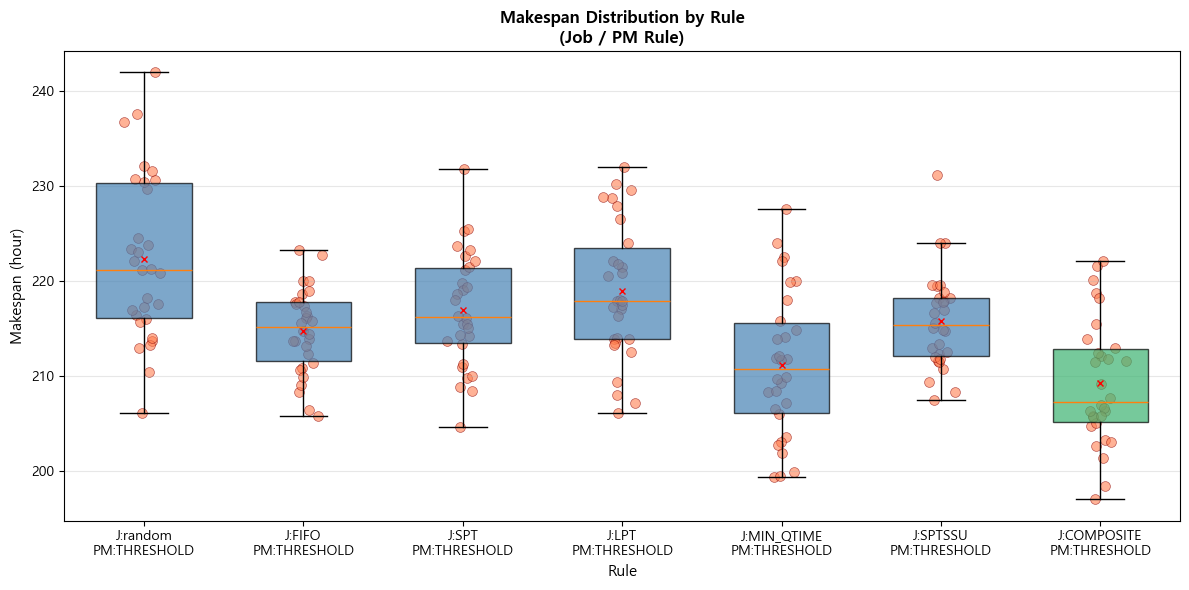

In [7]:
_unit_label = {'M': 'min', 'H': 'hour', 'D': 'day'}.get(os.getenv('TIME_UNIT', 'M'), 'min')
fig, ax = plt.subplots(figsize=(12, 6))

rule_indices = [(job_rule, pm_rule) for job_rule in JOB_RULES for pm_rule in PM_RULES]
rule_labels = [f"J:{idx[0]}\nPM:{idx[1]}" for idx in rule_indices]

box_data = [metrics_df[
    (metrics_df['job_rule'] == idx[0]) &
    (metrics_df['pm_rule'] == idx[1])
]['makespan'].values for idx in rule_indices]
box_colors = ['steelblue'] * len(box_data)

# COMPOSITE box 추가 (composite_metrics 가 있을 때만) — 다른 색으로 구분
if 'composite_metrics' in globals() and len(composite_metrics) > 0:
    rule_labels.append(f"J:COMPOSITE\nPM:{composite_metrics['pm_rule'].iloc[0]}")
    box_data.append(composite_metrics['makespan'].values)
    box_colors.append('mediumseagreen')

bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, data in enumerate(box_data):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    ax.scatter(x_jittered, data, alpha=0.6, s=50, color='coral', edgecolors='darkred', linewidth=0.5)
    ax.plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='red', zorder=3)

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel(f'Makespan ({_unit_label})', fontsize=11)
ax.set_title('Makespan Distribution by Rule\n(Job / PM Rule)', fontsize=12, fontweight='bold')

ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Qtime Violation

C:\Users\hun99\AppData\Local\Temp\ipykernel_34440\2082153364.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)


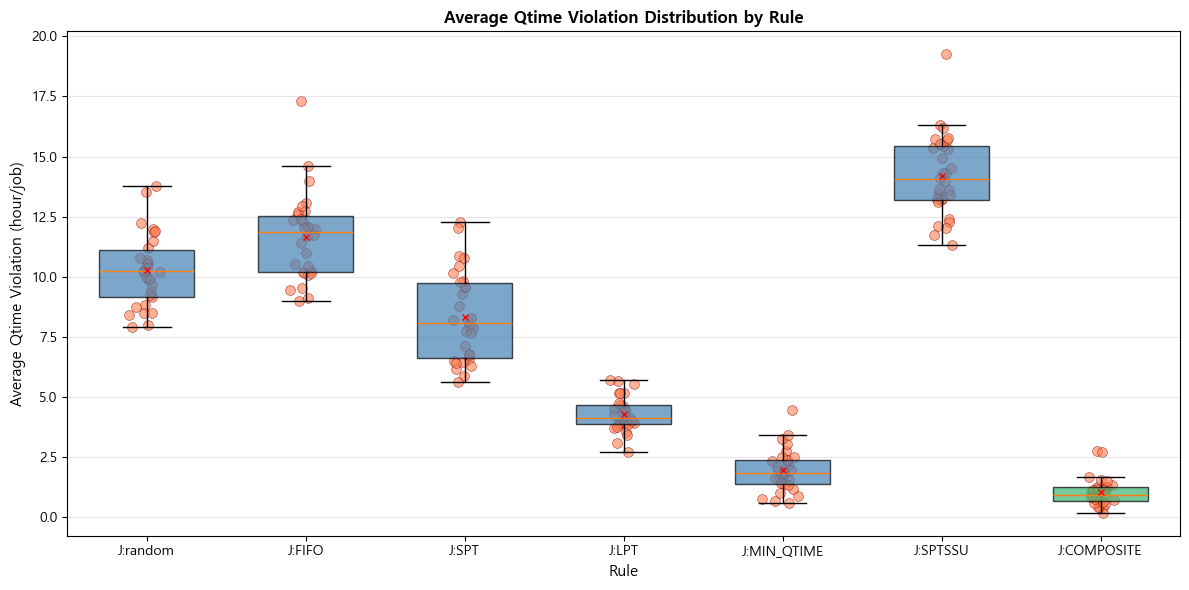

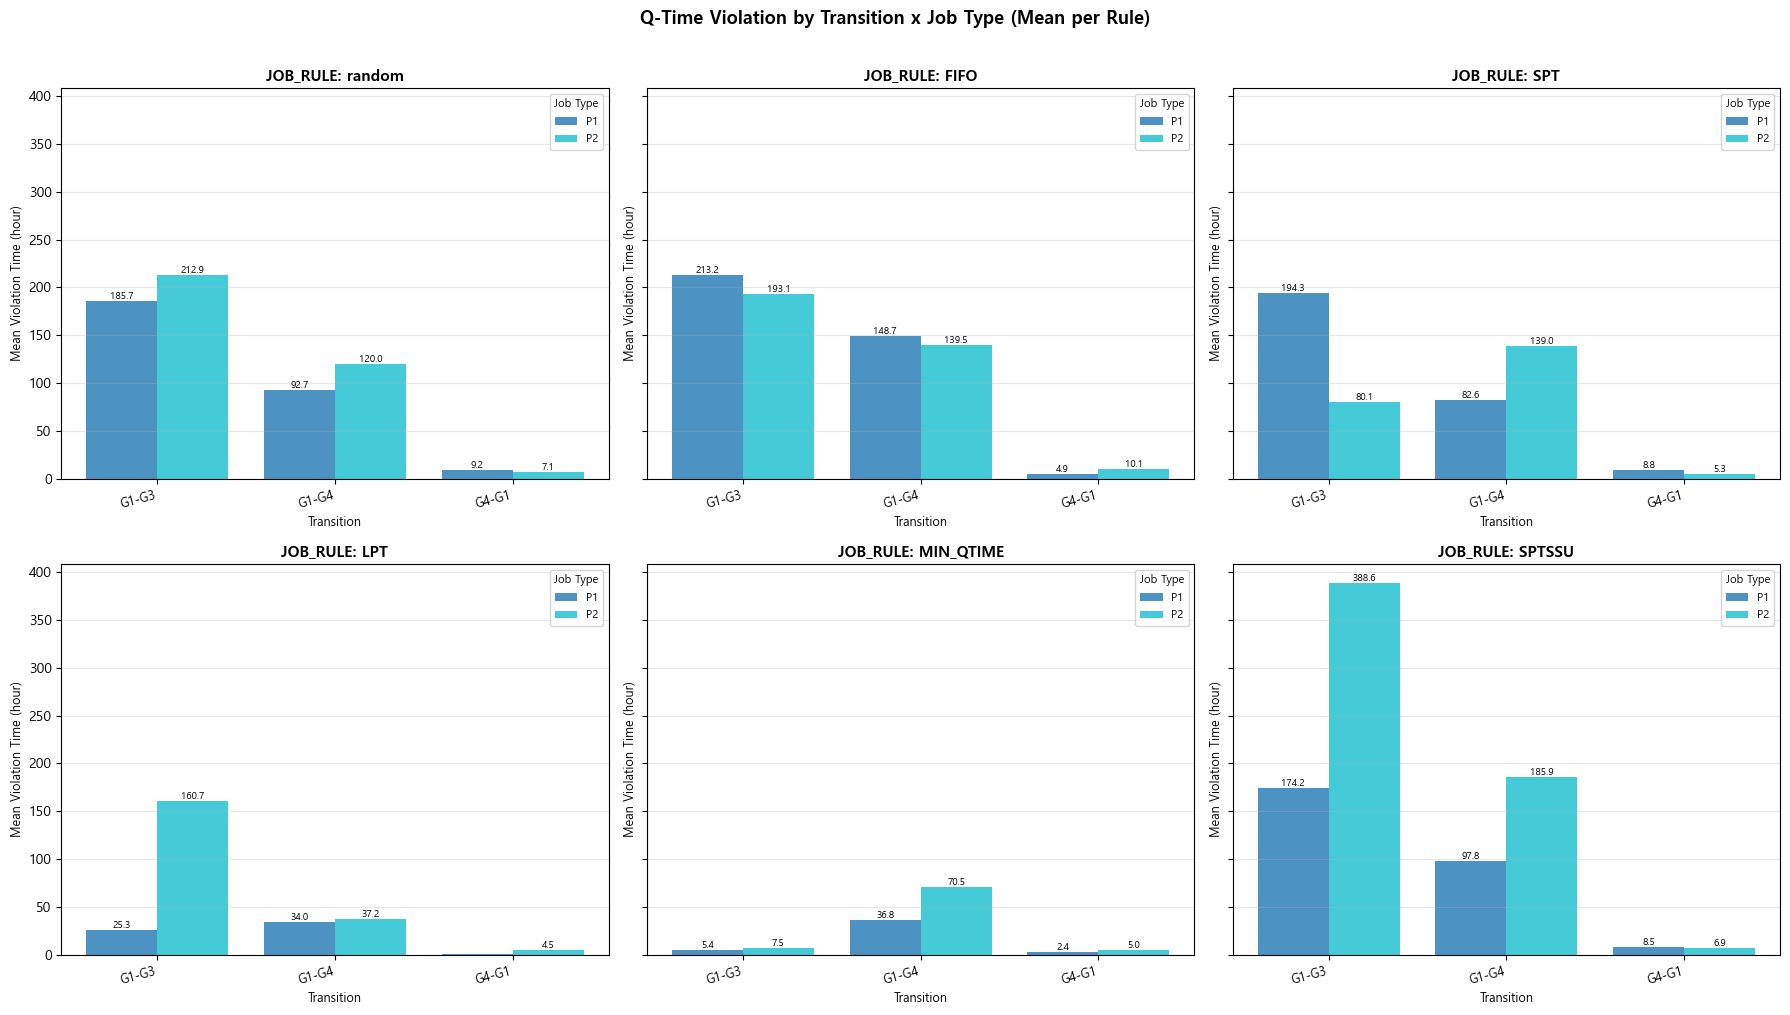

In [8]:
# ── 그래프 1: Rule별 Average Qtime Violation 분포 (boxplot) ───────────────────
# y축 = Average Qtime Violation = Total Qtime Violation / N_JOBS (job당 평균 위반 시간).
_unit_label = {'M': 'min', 'H': 'hour', 'D': 'day'}.get(os.getenv('TIME_UNIT', 'M'), 'min')

fig, ax = plt.subplots(figsize=(12, 6))

rule_indices = [(job_rule, pm_rule) for job_rule in JOB_RULES for pm_rule in PM_RULES]
rule_labels = [f"J:{idx[0]}" for idx in rule_indices]

# Total → Average: N_JOBS 로 나눈다.
box_data = [metrics_df[
    (metrics_df['job_rule'] == idx[0]) &
    (metrics_df['pm_rule'] == idx[1])
]['qtime_violations'].values / N_JOBS for idx in rule_indices]
box_colors = ['steelblue'] * len(box_data)

# COMPOSITE box 추가 (composite_metrics 가 있을 때만) — 다른 색으로 구분
if 'composite_metrics' in globals() and len(composite_metrics) > 0:
    rule_labels.append("J:COMPOSITE")
    box_data.append(composite_metrics['qtime_violations'].values / N_JOBS)
    box_colors.append('mediumseagreen')

bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, data in enumerate(box_data):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    ax.scatter(x_jittered, data, alpha=0.6, s=50, color='coral', edgecolors='darkred', linewidth=0.5)
    ax.plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='red', zorder=3)

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel(f'Average Qtime Violation ({_unit_label}/job)', fontsize=11)
ax.set_title('Average Qtime Violation Distribution by Rule', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 그래프 2: Qtime Violation — Transition × Job Type (rule별 서브플롯) ────────
# 전체 run의 transition_violation을 합산하여 long-form DataFrame 생성
tv_rows = []
for _, row in metrics_df.iterrows():
    if isinstance(row['transition_violation'], pd.Series) and len(row['transition_violation']) > 0:
        for (job_type, transition), val in row['transition_violation'].items():
            tv_rows.append({
                'job_rule': row['job_rule'],
                'pm_rule': row['pm_rule'],
                'job_type': job_type,
                'transition': transition,
                'violation': val
            })

tv_df = pd.DataFrame(tv_rows)

if len(tv_df) > 0:
    all_transitions = sorted(tv_df['transition'].unique())
    all_job_types = sorted(tv_df['job_type'].unique())
    n_rules = len(JOB_RULES)
    n_cols = 3
    n_rows = (n_rules + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=True)
    axes = axes.flatten()

    colors = plt.cm.tab10(np.linspace(0, 1, max(len(all_job_types), 1)))
    bar_width = 0.8 / max(len(all_job_types), 1)
    x = np.arange(len(all_transitions))

    for rule_idx, job_rule in enumerate(JOB_RULES):
        ax = axes[rule_idx]
        rule_df = tv_df[tv_df['job_rule'] == job_rule]

        pivot = rule_df.groupby(['transition', 'job_type'])['violation'].mean().unstack('job_type').reindex(
            index=all_transitions, columns=all_job_types, fill_value=0
        )

        for jt_idx, job_type in enumerate(all_job_types):
            offset = (jt_idx - (len(all_job_types) - 1) / 2) * bar_width
            vals = pivot[job_type].values if job_type in pivot.columns else np.zeros(len(all_transitions))
            bars = ax.bar(x + offset, vals, bar_width, label=job_type, color=colors[jt_idx], alpha=0.8)
            for bar in bars:
                h = bar.get_height()
                if h > 0.5:
                    ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}',
                            ha='center', va='bottom', fontsize=7)

        ax.set_title(f'JOB_RULE: {job_rule}', fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(all_transitions, rotation=15, ha='right', fontsize=9)
        ax.set_xlabel('Transition', fontsize=9)
        ax.set_ylabel(f'Mean Violation Time ({_unit_label})', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(title='Job Type', fontsize=8, title_fontsize=8)

    # 빈 서브플롯 숨기기
    for i in range(n_rules, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle('Q-Time Violation by Transition x Job Type (Mean per Rule)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No Q-Time violation data.")

## 목적함수 정규화 기준 (mk_ref, qv_ref) 산출 및 저장

목적함수: $J = w_1 \cdot Mk/\text{mk\_ref} + w_2 \cdot QV/\text{qv\_ref}$

| 기준 | 방식 | 산출 |
|---|---|---|
| `mk_ref` | 전체 관측값의 **최댓값** | 모든 baseline rule × 모든 반복(`N_RUNS`) 중 Makespan 최댓값 |
| `qv_ref` | 전체 관측값의 **최댓값** | 모든 baseline rule × 모든 반복(`N_RUNS`) 중 QV(총합) 최댓값 |

- 평균값의 최댓값이 아니라 **개별 시행 단위의 최댓값**을 사용 (분모를 가장 보수적으로 키워 정규화 항을 [0, 1] 안에 머물게 한다).
- 시드를 고정해(`SEED_BASE = 0`) 다른 노트북도 동일 시드 시행과 일관된 분모를 공유한다.

저장 결과는 `data/normalization_ref.json` (분 단위).

In [9]:
import json

_TIME_CONSTANTS = {'M': 1, 'H': 60, 'D': 60 * 24}
_TIME_UNIT = os.getenv('TIME_UNIT', 'M').upper()
to_minutes = _TIME_CONSTANTS.get(_TIME_UNIT, 1)

# N_JOBS는 데이터 로드 셀에서 캡처해 둔 값을 사용 (중간 셀들이 `data`를 덮어쓰므로
# 여기서 data['jobs']로 다시 접근하면 IndexError가 난다).
if 'N_JOBS' not in globals() or N_JOBS <= 0:
    raise RuntimeError("N_JOBS가 정의돼 있지 않다. 데이터 로드 셀(c7f6dd93)을 먼저 실행하라.")

# rule별 평균 (현재 TIME_UNIT 단위 -> 분 단위 환산)  ── 기존 요약 그대로
ref_df = metrics_df[metrics_df['job_rule'].isin(JOB_RULES)]
per_rule_raw = (ref_df.groupby('job_rule')[['makespan', 'qtime_violations']]
                .mean())
per_rule_min = per_rule_raw * to_minutes               # 분 단위 (총합 QV)
per_rule_aqt = per_rule_min['qtime_violations'] / N_JOBS  # AQT (분/job)

# mk_ref, qv_ref: rule별 평균의 최댓값이 아니라,
# 모든 baseline rule × 모든 반복(N_RUNS) 중 **개별 시행 단위 관측값의 최댓값** (분 단위)
mk_obs = ref_df['makespan'] * to_minutes
qv_obs = ref_df['qtime_violations'] * to_minutes

mk_ref = float(mk_obs.max())
qv_ref = float(qv_obs.max())

if qv_ref <= 0:
    qv_ref = 1.0

mk_argmax = ref_df.loc[mk_obs.idxmax()]
qv_argmax = ref_df.loc[qv_obs.idxmax()]
mk_best_rule, mk_best_try = mk_argmax['job_rule'], int(mk_argmax['try'])
qv_worst_rule, qv_worst_try = qv_argmax['job_rule'], int(qv_argmax['try'])

per_rule = {
    r: {'makespan': round(per_rule_min.loc[r, 'makespan'], 3),
        'qtime_violations_total': round(per_rule_min.loc[r, 'qtime_violations'], 3),
        'aqt': round(per_rule_aqt.loc[r], 3)}
    for r in per_rule_min.index
}

ref_payload = {
    'mk_ref': mk_ref,
    'qv_ref': qv_ref,
    'mk_ref_rule': mk_best_rule,
    'mk_ref_try': mk_best_try,
    'qv_ref_rule': qv_worst_rule,
    'qv_ref_try': qv_worst_try,
    'n_jobs': N_JOBS,
    'unit': 'M',
    'qv_ref_metric': 'QV_total',          # 총 QV(분) 기준 (개별 시행 최댓값)
    'mk_ref_method': 'observed_max',      # 모든 rule × 모든 반복의 개별 시행 최댓값
    'qv_ref_method': 'observed_max',
    'source_time_unit': _TIME_UNIT,
    'seed_base': int(SEED_BASE),
    'n_runs': int(N_RUNS),
    'rules': list(JOB_RULES),
    'per_rule_mean': per_rule,
}

ref_path = os.path.join(BASE_DATA_PATH, 'normalization_ref.json')
with open(ref_path, 'w', encoding='utf-8') as f:
    json.dump(ref_payload, f, ensure_ascii=False, indent=2)

print(f"TIME_UNIT(.env) = {_TIME_UNIT}  ->  분 단위로 환산하여 저장 (×{to_minutes})")
print(f"SEED_BASE = {SEED_BASE}, N_RUNS = {N_RUNS}, N_JOBS = {N_JOBS}")
print(f"mk_ref = {mk_ref:.3f} (분)   [observed max  <- {mk_best_rule}, try={mk_best_try}]")
print(f"qv_ref = {qv_ref:.3f} (분)   [observed max  <- {qv_worst_rule}, try={qv_worst_try}]")
print(f"saved -> {ref_path}\n")
print("rule별 평균 (분 단위):")
for r, v in per_rule.items():
    mk_mark = '  <- mk_ref(rule)' if r == mk_best_rule else ''
    qv_mark = '  <- qv_ref(rule)' if r == qv_worst_rule else ''
    print(f"  {r:10s}  Mk={v['makespan']:.1f}{mk_mark}   "
          f"QV_total={v['qtime_violations_total']:.1f}   AQT={v['aqt']:.2f}{qv_mark}")

TIME_UNIT(.env) = H  ->  분 단위로 환산하여 저장 (×60)
SEED_BASE = 0, N_RUNS = 30, N_JOBS = 60
mk_ref = 14515.053 (분)   [observed max  <- random, try=22]
qv_ref = 69320.321 (분)   [observed max  <- SPTSSU, try=24]
saved -> data\normalization_ref.json

rule별 평균 (분 단위):
  FIFO        Mk=12883.9   QV_total=41984.9   AQT=699.75
  LPT         Mk=13134.1   QV_total=15387.1   AQT=256.45
  MIN_QTIME   Mk=12669.0   QV_total=7008.0   AQT=116.80
  SPT         Mk=13016.6   QV_total=29968.6   AQT=499.48
  SPTSSU      Mk=12946.4   QV_total=51065.2   AQT=851.09  <- qv_ref(rule)
  random      Mk=13337.8  <- mk_ref(rule)   QV_total=36939.0   AQT=615.65


## Rule별 Makespan / AQT / Objective Value(J) 요약 표

각 dispatching rule(+ `COMPOSITE`)의 `N_RUNS`회 평균 Makespan·AQT와, 위에서 산출한 정규화 기준(`mk_ref`, `qv_ref`)으로 계산한 목적함수
$J = w_1\cdot Mk/\text{mk\_ref} + w_2\cdot QV_\text{total}/\text{qv\_ref}$ ($w_1=w_2=1$) 를 한 표로 정리한다. (`rule_objective_summary.xlsx` 로도 저장)

In [10]:
# ── Rule × Makespan / AQT / Objective Value(J) 요약 표 ────────────────────────
# J = w1·Mk/mk_ref + w2·QV_total/qv_ref  (위 셀에서 산출한 mk_ref, qv_ref 사용 — 분 단위)
# COMPOSITE 는 composite_metrics 가 있을 때만 마지막 행으로 추가.
if 'mk_ref' not in globals() or 'qv_ref' not in globals():
    raise RuntimeError("mk_ref / qv_ref 가 없다. 위의 정규화 기준 셀(6aa1095b)을 먼저 실행하라.")

_to_min = {'M': 1, 'H': 60, 'D': 60 * 24}.get(os.getenv('TIME_UNIT', 'M').upper(), 1)
W1, W2 = 1.0, 1.0  # 목적함수 가중치 (CLAUDE.md 기본값)

RULE_DESC = {
    'random':    'Random',
    'FIFO':      'First In First Out',
    'SPT':       'Shortest Processing Time',
    'LPT':       'Longest Processing Time',
    'MIN_QTIME': 'Minimum Remaining Q-Time',
    'SPTSSU':    'Shortest Processing Time and Shortest Setup Unit',
    'COMPOSITE': 'Multiple Priority Terms',
}

# baseline rule별 평균 (TIME_UNIT → 분 환산)
_base_mean = metrics_df.groupby('job_rule')[['makespan', 'qtime_violations']].mean() * _to_min

# (rule_key, display_label, mk_min, qv_total_min) — JOB_RULES 순서 + 마지막에 COMPOSITE
_parts = [(r, r.upper(), _base_mean.loc[r, 'makespan'], _base_mean.loc[r, 'qtime_violations'])
          for r in JOB_RULES]
if 'composite_metrics' in globals() and len(composite_metrics) > 0:
    _cm = composite_metrics[['makespan', 'qtime_violations']].mean() * _to_min
    _parts.append(('COMPOSITE', 'COMPOSITE', _cm['makespan'], _cm['qtime_violations']))

_rows = []
for key, label, mk_min, qv_min in _parts:
    aqt_min = qv_min / N_JOBS                              # AQT = QV_total / N_JOBS (분/job)
    J = W1 * (mk_min / mk_ref) + W2 * (qv_min / qv_ref)    # 정규화 목적함수
    _rows.append({
        'Rule': label,
        'Makespan (hour)': round(mk_min / 60.0, 2),
        'AQT (hour)': round(aqt_min / 60.0, 3),
        'Objective Value (J)': round(J, 4),
        'Description': RULE_DESC.get(key, ''),
    })

summary_table = pd.DataFrame(_rows, columns=[
    'Rule', 'Makespan (hour)', 'AQT (hour)', 'Objective Value (J)', 'Description'
])

print(f"mk_ref = {mk_ref:.1f} (분), qv_ref = {qv_ref:.1f} (분)   |   J = Mk/mk_ref + QV_total/qv_ref")
print(summary_table.to_string(index=False))

# 엑셀로도 저장
_out = 'rule_objective_summary.xlsx'
summary_table.to_excel(_out, index=False)
print(f"\nsaved → {_out}")

summary_table

mk_ref = 14515.1 (분), qv_ref = 69320.3 (분)   |   J = Mk/mk_ref + QV_total/qv_ref
     Rule  Makespan (hour)  AQT (hour)  Objective Value (J)                                      Description
   RANDOM           222.30      10.261               1.4518                                           Random
     FIFO           214.73      11.662               1.4933                               First In First Out
      SPT           216.94       8.325               1.3291                         Shortest Processing Time
      LPT           218.90       4.274               1.1268                          Longest Processing Time
MIN_QTIME           211.15       1.947               0.9739                         Minimum Remaining Q-Time
   SPTSSU           215.77      14.185               1.6286 Shortest Processing Time and Shortest Setup Unit
COMPOSITE           209.24       1.054               0.9196                          Multiple Priority Terms

saved → rule_objective_summary.xlsx


,Rule,Makespan (hour),AQT (hour),Objective Value (J),Description
0,RANDOM,222.30,10.261,1.4518,Random
1,FIFO,214.73,11.662,1.4933,First In First Out
2,SPT,216.94,8.325,1.3291,Shortest Processing Time
3,LPT,218.90,4.274,1.1268,Longest Processing Time
4,MIN_QTIME,211.15,1.947,0.9739,Minimum Remaining Q-Time
5,SPTSSU,215.77,14.185,1.6286,Shortest Processing Time and Shortest Setup Unit
6,COMPOSITE,209.24,1.054,0.9196,Multiple Priority Terms
